- 단어의 분산 표현을 추론 기반 기법으로 처리, 추론 기반 기법은 추론을 하는 기법으로 추론과정에 신경망을 이용, 여기서 word2vec등장
- 이번장의 목표는 단순한 word2vec 구현

- 3.1 추론 기반 기법과 신경망
    - 단어를 벡터로 표현하는 방법은 크게 2가지, 통계 기반 기법, 추론 기반 기법

- 3.1.1 통계 기반 기법의 문제점
    - 통계 기반 기법에서는 주면 단어의 빈도를 기초로 단어를 표현, 구체적으로는 단어의 동시발생 행렬을 만들고 그 행렬에 SVD를 적용하여 밀집벡터(단어의 분산 표현)를 얻은, 그러나 이 방식은 대규모 말뭉치를 다룰 때 문제가 발생
    - 어휘가 100만개 라면 통계 기반 기법에서는 100만 x 100만 이라는 거대한 행렬이 생성
    - 통계 기반 기법은 말뭉치 전체의 통계(동시발생 행렬과 PPMI 등)를 이용해 단 1회의 처리(SVD 등)만에 단어의 분산 표현을 얻음
    - 추론 기반 기법에서는 신경망을 이용해 미니배치로 학습하는 것이 일반적, 미니배치 학습에서는 신경망이 한번에 소량(미니배치)의 학습 샘플씩 반복해서 학습하여 가중치를 갱신, 아래 그림 참조
    - 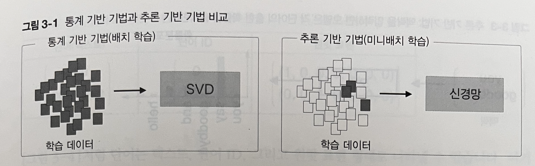
    - 위 그림처럼 통계 기반 기법은 학습 데이터를 한꺼번에 처리(배치 학습), 이에 반해 추혼 기반 기법은 학습 데이터의 일부를 사용하여 순차적으로 학습(미니배치 학습), 이 말은 말충치의 어휘수가 많아 SVD 등 계산량이 큰 작업을 처리하기 어려운 경우에도 신경망 학습이 가능, 데이터를 작게 나눠 학습하기 때문
    - 거기에 여러 머신과 여러 GPU를 이용해 병렬 계산도 가능해져서 학습 속도를 높일 수 있음

- 3.1.2 추론 기반 기법 개요
    - 추론 기반 기법에서는 당연히 추론이 주된 작업, 추론이란 아래 그림 처럼 주변 단어(맥락)가 주어졌을 때 "?"에 무슨 단어가 들어가는 지를 추축하는 작업
    - 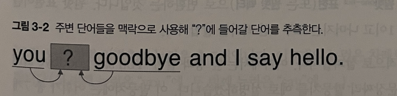
    - 위 그림에서 처럼 추론 문제를 풀고 학습하는 것이 추론 기반 기법이 다루는 문제, 이러한 추론 문제를 반복해서 풀면서 단어의 출현 패턴을 학습, 모델 관점에서 보면 이 추론 문제는 아래 그림처럼 보임
    - 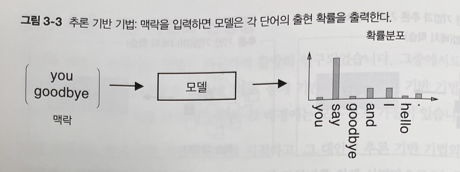
    - 위 그림처럼 추론 기반 기법에는 어떠한 모델이 등장, 이 모델로 신경망을 사용
    - 모델은 맥락 정보를 입력받아 출현할 수 있는 각 단어의 출현 확률을 출려그 이러한 틀 안에서 말뭉치를 사용해 모델이 올바른 추측을 내놓도록 학습, 그리고 그 학습의 결과로 단어의 분산표현을 얻는 것이 추론 기반 기법의 전체 그림
    - 추론 기반 기법도 통계 기반 기법처럼 분포 가설에 기초, 분포 가설이란 단어의 의미는 주변 단어에 의해 형상된다는 가설로, 추론 기반 기법에서는 이를 앞에서와 같은 추측 문제로 귀결시킴, 이처럼 두 기법 모두 분포 가설에 근거하여 단어의 동시발생 가능성을 얼마나 잘 모델링 하는 가가 중요한 연구 주제

- 3.1.3 신경망에서의 단어 처리
    - 신경망을 이용해 단어를 처리, 신경망은 you와 say 등의 단어를 있는 그대로 처리할 수 없으니 단어를 고정 길리 벡터로 변환해야 함, 이때 사용하는 대표적인 방법이 단어를 원핫(one-hot) 표현(또는 원핫 벡터)으로 변환하는 것, 원핫 표현이란 벡터의 원소 중 하나만 1이고 나머지는 모두 0인 벡터
    - 원핫 표현에 대해 구체적으로 살펴보면, You say goodbye and I say hello 라는 한 문장짜리 말뭉치를 예로 들어, 이 말뭉치에는 어휘가 총 7개 등장(you, say, goodbye, and, i, hello, "."), 이중 두 단어의 원핫 표현을 아래 그림처럼 나타냄
    - 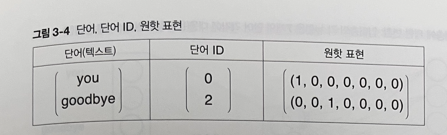
    - 위 그림처럼 단어는 텍스트, 단어ID, 원핫 표현 형태로 나타낼 수 있음, 여기서 단어를 원핫 표현으로 변환하는 방법은 먼저 총 어휘 수만큼의 원소를 갖는 벡터를 준비하고, 인덱스가 단어ID와 같은 원소를 1로 나머지는 모두 0으로 설정, 이처럼 단어를 고정 길이 벡터로 변환하는 우리 신경망의 입력층은 아래 그림처럼 뉴런의 수를 고정할 수 있음
    - 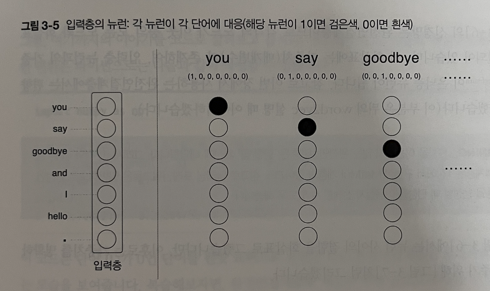
    - 위 그림처럼 입력층의 뉴런은 총 7개, 이 7개의 뉴런은 차례로 7개의 단어들에 대응(첫 번째 뉴런은 you, 두 번째 뉴런은 say...)
    - 단어를 백터로 나타낼 수 있고,신경망을 구성하는 계층들은 벡터를 처리할 수 있음, 다시 말해 단어를 신경망으로 처리 가능, 아래 그림과 같이 원핫 표현으로 된 단어 하나를 완전연결계층을 통해 변환하는 모습을 확인
    - 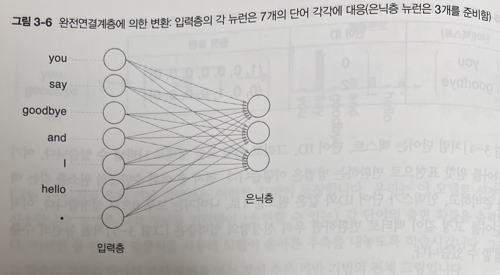
    - 위 그림처럼 신경망은 완전연결계층이므로 각각의 노드가 이웃 층의 모든 모드와 화살표로 연결되어 있음, 이 화살표에는 가중치(매개변수)가 존재하며, 입력층 뉴런과의 가중합이 은닉층의 뉴런이 됨, 이번 장에서는 완전연결계층에 편향은 생략, 편향을 이용하지 않는 완전연결계층은 [행렬 곱] 계산에 해당
    - 위 그림에서는 뉴런 사이의 결합을 화살표로 표시했지만 이후로는 아래 그림과 같이 가중치를 명확하게 보여주게 그림
    - 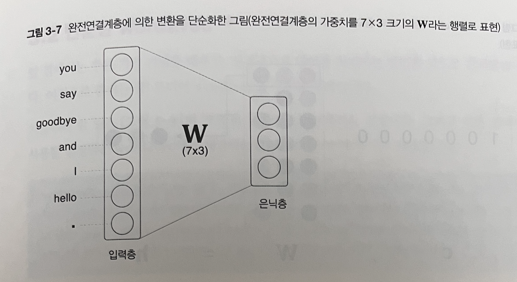

In [261]:
import numpy as np

c = np.array([[1, 0, 0, 0, 0, 0, 0]])       # 입력
W = np.random.randn(7, 3)                   # 가중치
h = np.matmul(c, W)                         # 중간 노드

print(h)

[[-2.12279412  0.65210191 -0.03448923]]


- 위 코드는 단어ID가 0인 단어를 원핫 표현으로 표현한 다음 완전연결계층을 통과시켜 변환하는 모습을 보여줌, 완전연결계층의 계산은 행렬 곱으로 수행할 수 있고, 행렬 곱은 넘파이의 np.matmul() 로 처리 가능
- 이 코드에서 입력 데이터(c)의 차원수(ndim)는 2, 이는 미니배치 처리를 고혀한 것, 최초의 차원(0번째 차원)에 각 데이터를 저장
- 위 코드에서 주목할 곳은 c와 W의 행렬 곱 부분, c는 원핫 표현이므로 단어ID에 대응하는 원소만 1이고 그 외에는 0인 벡터, 따라서 c와 W의 행렬 곱은 결국 아래 그림처럼 가중치의 행 벡터 하나를 뽑이낸 것과 같음
- 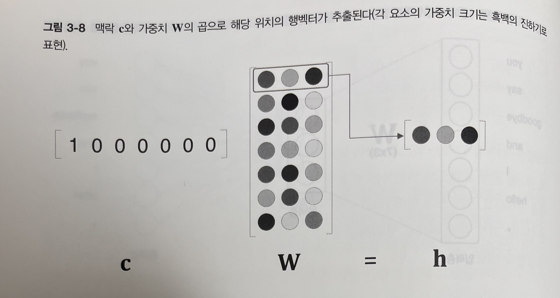
- 그저 가중치로부터 행벡터를 뽑아낼 뿐인데 행렬 곱을 계산하는 것인 다소 비효율적, 아래 코드에서 개선

In [262]:
class MatMul:
    def __init__(self, W):
        self.params = [W]
        self.grads = [np.zeros_like(W)]
        self.x = None

    def forward(self, x):
        W, = self.params
        out = np.dot(x, W)
        self.x = x
        return out
    
    def backward(self, dout):
        W, = self.params
        dx = np.dot(dout, W.T)
        dW = np.dot(self.x.T, dout)
        self.grads[0][...] = dW
        return dx

In [263]:
import sys
sys.path.append("..")
import numpy as np

c = np.array([[1, 0, 0, 0, 0, 0, 0]])
W = np.random.randn(7, 3)
layer = MatMul(W)
h = layer.forward(c)

print(h)

[[-0.72903697  0.47731356  0.54173557]]


- MatMul 계층에 가중치 W를 설정하고 forward() 메서드를 호출 해 순전파를 수행

- 3.2 단순한 word2vec
    - word2vec 구현, word2vec에서 제안하는 CBOW(continuous bag-of-words) 모델
    - word2vec이라는 용어는 원래 프로그램이나 도구를 가키키는 데 사용, 그런데 이 용어가 유명해지면서 문맥에 따라서는 신경망 모델을 가리크는 경우도 있음
    - CBOW 모델과 skip-gram 모델은 word2vec에서 사용되는 신경망

- 3.2.1 CBOW 모델의 추론 처리
    - CBOW 모델은 맥락으로부터 타깃을 추측하는 용도의 신경망(타깃은 중앙 단어이고 그 주변 단어들이 맥락), 이 CBOW 모델이 가능한 한 정확하게 추론하도록 훈련시켜 단어의 분산 표현을 얻어낼 것
    - CBOW 모델의 입력은 맥락, 맥락은 you와 goodbye 같은 단어들의 목혹, 가장 먼저, 이 맥락을 원핫 표현으로 변환하여 CBOW 모델이 처리할 수 있도록 준비
    - 이상을 기초로 CBOW 모델의 신경망을 아래 그림처럼 표시 가능
    - 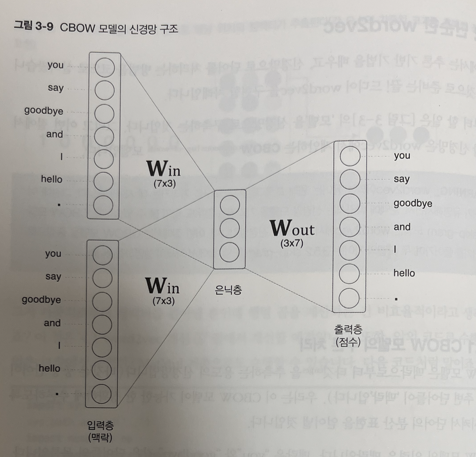
    - 위 그림은 CBOW 모델의 신경망, 입력층이 2개 있고, 은닉층을 거쳐 출력층에 도달, 두 입력층에서 은닉층으로의 변환은 똑같은 완전연결계층(가중치는 W_in)이 처리, 그리고 은닉층에서는 출력층 뉴런으로의 변환은 다른 완전연결계층(가중치는 W_out)이 처리
    - 위 그림에서 입력층이 2개인 이유는 맥락으로 고려할 단어를 2개로 정했기 때문, 즉 맥락에 포함시킬 단어가 N개라면 입력층도 N개가 됨
    - 위 그림의 은닉층을 보면, 은닉층의 뉴런은 입력층의 완전연결계층에 의해 변환된 값이 되는데, 입력층이 여러 개이면 전체를 평균하게 됨
    - 앞의 예에 대입해보면 다음과 같음, 완전연결계층에 의한 첫 번째 입력층의 h_1으로 변환, 두 번째 입력층이 h_2로 변환되었다고 하면 은닉층의 뉴런은 1/2(h_1 + h_2)가 됨
    - 마지막으로 위 그림의 출력층을 보면, 출력층의 뉴런은 총 7개, 여기서 중요한 것은 이 뉴런 하나하나가 각각의 단어에 대응, 그리고 출력층 뉴런은 각 단어의 점수를 뜻하며, 값이 높을수록 대응 단어의 출현 확률도 높아짐, 여기서 점수란 확률로 해석되기 전의 값이고, 이 점수에 소프트맥스 함수를 적용해서 확률을 얻을 수 있음
    - 점수를 Softmax 계층에 통과시킨 후의 뉴런을 출력층이라고도 함
    - 위 그림처럼 입력층에서 은닉층으로의 변환은 완전연결계층(가중치는 W_in)에 의해서 이루어짐, 이때 완전연결계층의 가중치 W_in은 7x3 행렬이며, 이 가중치가 바로 단어의 분산 표현의 정체, 그림으로 표현하면 아래와 같음
    - 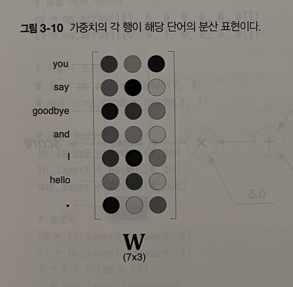
    - 위 글미에서 보듯 가중치 W_in의 각 행에는 해당 단어의 분산 표현이 담겨있음, 따라서 학습을 진행할수록 맥락에서 출현하는 단어를 잘 추측하는 방향으로 이 분산 표현들이 갱신, 그리고 이렇게 얻은 벡터에서 단어의 의미도 잘 녹아들어 있음, 이것이 word2vec의 전체 그림
    - 은닉층의 뉴런 수를 입력층의 뉴런 수보다 적게 하는 것이 중요한 핵심, 이렇게 해야 은닉층에는 단어 예측에 필요한 정보를 간결하게 담게되며, 결과적으로 밀집벡터 표현을 얻을 수 있음, 이때 은닉층의 정보는 사람이 이해할 수 없는 코드로 쓰여있음, 바로 인토딩에 해당, 한편 은닉층의 정보로부터 원하는 결과를 얻는 작업은 디코딩이라고 함, 즉 디코딩이란 인코딩된 정보를 사람이 이해할 수 있는 표현으로 복원하는 작업
    - 지금까지 CBOW 모델을 뉴런 관점에서 그려왔는데 이것을 계층 관점에서 그려 보면 아래 그림과 같음 
    - 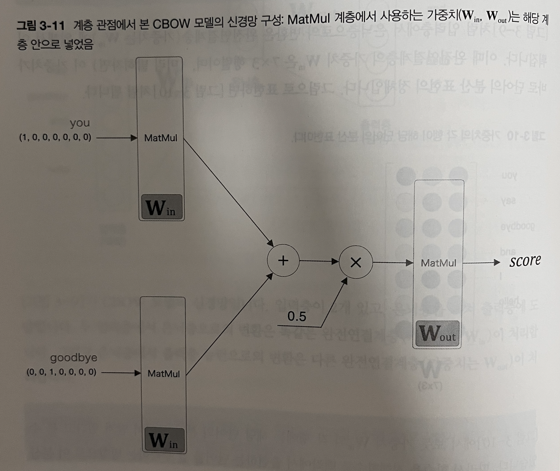
    - 위 그림에서 알 수 있듯이 CBOW 모델의 가장 앞단에는 2개의 MatMul 계층이 있고, 이어서 이 두 계층의 출력이 더해짐, 그리고 더해진 값에 0.5를 곱하면 평균이 되고, 이 평균은 은닉층 뉴런이 됨, 마지막으로 은닉층 뉴런에 또 다른 MatMul 계층이 적용되어 점수가 출력
    - 편향을 사용하지 않는 완전연결 계츨의 처리는 MatMul 계층의 순전파와 같음, MatMul 계층은 내부에서 행렬 곱을 계산

In [264]:
import numpy as np

# 샘플 맥락 데이터
c0 = np.array([[1, 0, 0, 0, 0, 0, 0]])
c1 = np.array([[0, 0, 1, 0, 0, 0, 0]])

# 가중치 초기화
W_in = np.random.randn(7, 3)
w_out = np.random.randn(3, 7)

# 계층 생성
in_layer0 = MatMul(W_in)
in_layer1 = MatMul(W_in)
out_layer = MatMul(w_out)

# 순전파
h0 = in_layer0.forward(c0)
h1 = in_layer0.forward(c1)
h = 0.5 * (h0 + h1)
s = out_layer.forward(h)

print(s)

[[-0.0083137  -0.01092997 -0.13987588  0.20299401 -0.07291192 -0.01437783
  -0.07490908]]


- 이 코드에서는 가장 먼저, 필요한 가중치들(W_in과 W_out)을 초기화, 그리고 입력층을 처리하는 MatMul 계층을 맥락 수만큼(여기서는 2개) 생성, 출력층 측의 MatMul 계층은 1개만 생성, 이때 입력층 측의 MatMul 계층은 가중치 W_in을 공유
- 다음은 입력층 측의 MatMul 계층들 (in_layer0과 in_layer1)의 forward() 메서드를 호출 해 중간 데이터를 계싼하고, 출력층 측의 MatMul 계층(out_layer)을 통과시ㅕ 각 단어의 점수를 구함
- 이상이 CBOW 모델의 추론 과정, 이제 CBOW 모델의 학습으로 진행

- 3.2.2 CBOW 모델의 학습
    - 위에서 까지 CBOW 모델은 출력층에서 각 단어의 점수를 출력함, 이 점수에 소프트맥스 함수를 적용하면 확률을 얻을 수 있음, 이 확률은 맥락(전후 단어)이 주어졌을 때 그 중앙에 어떤 단어가 출현하는 지를 나타냄
    - 아래 그림의 예에서 맥락은 you와 goobbye이고 정답 레이블(신경망이 예측해야 할 단어)은 say 임, 이때 가중치가 적절히 설정된 신경망이라면 확률을 나타내는 뉴런들 중 정답에 해당하는 뉴런의 값이 클 것이라 기대 가능
    - 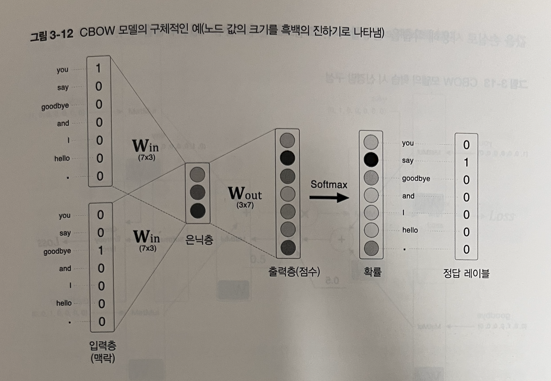
    - CBOW 모델의 학습에서는 올바른 예측을 할 수 있도록 가중치를 조정하는 일을 함, 그 결과로 가중치 W_in에(정화ㅏㄱ하게는 W_in과 W_out 모두에) 단어의 출현 패턴을 파악한 벡터가 학습, 그리고 지금까지의 실험에 의해 CBOW 모델(과 skip-gram 모델)로 얻을 수 있는 단어의 분한 표현은 단어의 의미면에서나 문법 면에서 모두 사람의 직관에 부합하는 경우를 많이 볼수 있음
    - CBOW 모델은 단어 출현 패턴을 학습 시 사용한 말뭉치로부터 학습, 따라서 말뭉치가 다르면 학습 후 얻게 되는 단어의 분산 표현도 달라짐, 예컨데 말뭉치로 스포츠 기사만을 사용하는 경우와 음악 관련 기사만을 사용하는 경우는 얻게 되는 단어의 분산 표현이 크게 다름
    - 현재 다루고 있는 모델은 다중 클래스 분류를 수핸하는 신경망 따라서 신경망을 학습하려면 소프트맥스와 교차 엔트로피 오차만 이용하면 됨, 여기에서는 소프트맥스 함수를 이용해 점수를 확률로 변환하고, 그 확률과 정답 레이블로부터 교차 엔트로피 오차를 구한 후, 그 값을 손실로 사용해 학습을 진행, 아래 그림과 같음
    - 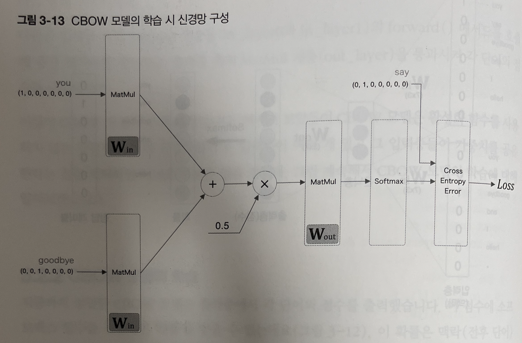
    - 위 그림에서 보듯 앞 절에서 설명한 추론 처리를 수행하는 CBOW 모델에 Softmax 계층과 Cross Entropy Error 계층을 추가, 이것으로 손실을 얻을 수 있음
    - 이상이 CBOW 모델의 손실을 구하는 계산의 흐름이자, 이 신경망의 순방향 전파
    - 위 그림에서는 Softmax 계층과 Cross Entropy Error 계층을 사용했지만 두 계층을 Softmax with Loss 라는 하나의 계층으로도 구현 가능, 아래 그림 참조
    - 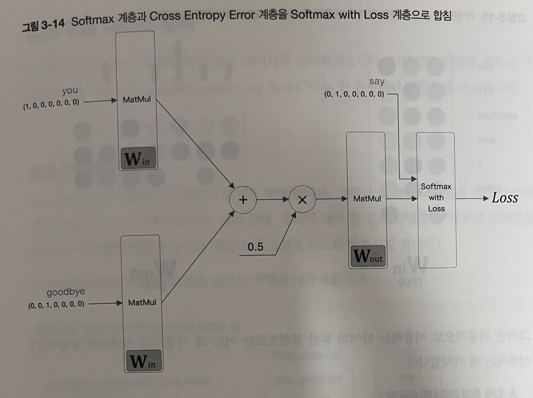

- 3.2.3 word2vec의 가중치와 분산 표현
    - word2vec에서 사용되는 신경망에는 두 가지 가중치가 있음, 입력 측 완전연결계층의 가중치(W_in)와 출력 측 완전연결계층의 가중치(W_out), 그리고 입력 측 가중치 W_in의 각 행이 단어의 분산 표현에 해당, 또한 출력 측 가중치 W_out에도 단어의 의미가 인코딩된 벡터가 저장되어 있음, 다만 출력 측 가중치는 아래 그림에서 보듯 각 단어의 분산 표현이 열 방향(수직 방향)으로 저장
    - 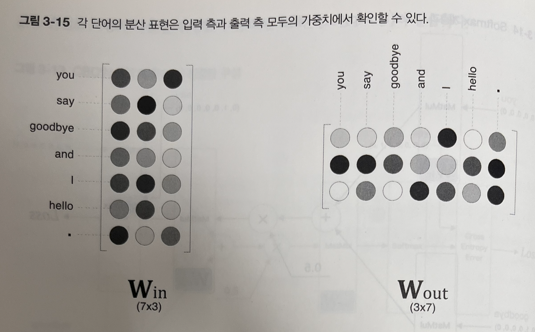
    - 최종적으로 이용하는 단어의 분산 표현으로는 어느쪽 가중치를 선택하면 좋을지 고민이 필요
        - A. 입력 측의 가중치만 이용
        - B. 출력 측의 가중치만 이용
        - C. 양쪽 가중치를 모두 이용
    - A와 B안은 어느 한쪽 가중치만 이용한다는 것, 마지막 C는 두 가중치ㄴ를 어떻게 조하바하느냐에 따라 다시 몇 가지 방법을 생각할 수 있음, 그 중 하나는 두 가중치를 단순하게 합치는 것
    - word2vec(특히 skip-gram 모델)에서는 A안인 입력 륵의 가중치만 이용 이 가자우 일반적인 선택, 많은 연구에서 출력 측 가중치는 버리고 입력 측 가중치 W_in만을 최종 단어의 분산 표현으로서 이용

- 3.3 학습 데이터 준비
    - word2vec 학습에 사용할 학습 데이터 준비, 간단하게 You say goodbye and I say hello. 라는 한 문장짜리 말뭉치 사용

- 3.3.1 맥락과 타깃
    - word2vec에서 이용하는 신경망의 입력은 맥락, 그리고 그 정답 레이블은 맥락에 둘러싸인 중앙의 단어, 즉 타겟, 다시 말해 신경망에 맥락을 입력했을 때 타겟이 출현할 확률을 높이게 학습 시키는 것이 목표
    - 아래 그림은 말뭉치에서 맥락과 타깃을 만드는 작업
    - 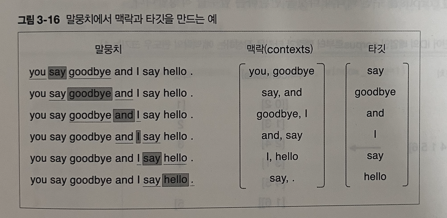
    - 위 그림에서는 말뭉치로부터 목표로 하는 단어를 타겟으로, 그 주변 단어를 맥락으로 뽑아냄, 이 작업을 말뭉치 안의 양끝 단어를 제외한 모든 단어에 대하 수행, 이렇게 만들어진 것이 아래 그림의 오른쪽에 있는 맥락과 타겟
    - 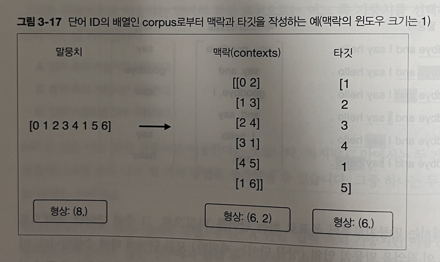
    - 이 맥락의 각 행이 신경망의 입력으로 쓰이고, 타겟의 각 행이 정답 레이블(예측해야 하는 단어)이 됨, 참고로 각 샘플 데이터에서 맥락의 수는 여러 개(이 예에서는 2개)가 될 수 있으나, 타겟은 오직 하나뿐

In [265]:
import numpy as np

# 말 뭉치 텍스트를 단어 ID 로 변환을 위한 preprocess() 함수
def preprocess(text):
    text = text.lower()
    text = text.replace(".", " .")
    words = text.split(" ")

    word_to_id = {}
    id_to_word = {}

    for word in words:
        if word not in word_to_id:
            new_id = len(word_to_id)
            word_to_id[word] = new_id
            id_to_word[new_id] = word
    
    corpus = np.array([word_to_id[w] for w in words])

    return corpus, word_to_id, id_to_word

In [266]:
text = "You say goodbye and I say hello."
corpus, word_to_id, id_to_word = preprocess(text)

print(corpus)

print(id_to_word)

[0 1 2 3 4 1 5 6]
{0: 'you', 1: 'say', 2: 'goodbye', 3: 'and', 4: 'i', 5: 'hello', 6: '.'}


- 위 코드에서 말뭉치 텍스트를 단어 ID로 변환
- 단어 ID 배열인 corpus로 부터 맥락과 타겟을 만들어 냄, 아래 그림과 같이 corpus를 주면 맥락과 타겟으로 변환하는 함수 작성 필요
- 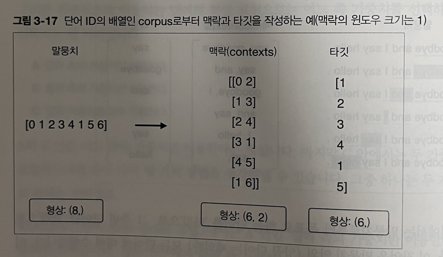
- 위 그림과 같이 맥락은 2차원 배열, 이때 맥락의 0번째 차원에는 각 맥락 데이터가 저장, contexts[0]에는 0번째 맥락이 저장되고, contexts[1]에는 1번째 맥락이 저장, 타겟에서도 target[0]에는 0번째 타겟이, target[1]에는 1번째 타깃이 저장

In [267]:
def create_contexts_target(corpus, window_size=1):
    target = corpus[window_size:-window_size]
    contexts = []

    for idx in range(window_size, len(corpus) - window_size):
        cs = []
        for t in range(-window_size, window_size + 1):
            if t == 0:
                continue

            cs.append(corpus[idx + t])
        
        contexts.append(cs)

    return np.array(contexts), np.array(target)

- 위 함수는 2개의 매개변수를 전달 받은, 하나는 단어 ID 배열(corpus), 다른 하나는 맥락의 윈도우 크기(window_size), 그리고 맥락과 타겟을 각각 넘파이 다차원 배열로 리턴

In [268]:
contexts, target = create_contexts_target(corpus, window_size=1)

print(contexts)

print(target)

[[0 2]
 [1 3]
 [2 4]
 [3 1]
 [4 5]
 [1 6]]
[1 2 3 4 1 5]


- 위 함수로 말뭉치로부터 맥락과 타겟을 생성, 이를 원학 표현으로 변환 필요

- 3.3.2 원핫 표현으로 변환
    - 맥락과 타겟을 원하 표현으로 변환이 필요, 아래 그림 참조
    - 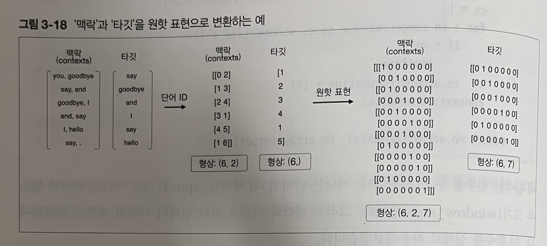
    - 위 그림의 예처럼 맥락과 타겟을 단어 ID에서 원핫 표현으로 변환, 이 때 각각의 다차원 배열의 형상에 주목할 필요가 있음, 위 그림을 보면 단어 ID를 이용했을 때 맥락의 형상은 (6,2)인데 이를 원핫 표현으로 변환하면 (6, 2, 7)

In [269]:
# 원핫 표현으로 변환하는 convert_one_hot() 함수
def convert_one_hot(corpus, vocab_size):
    # 1번째 매개변수: corpus(단어 ID 목록)
    # 2번째 매개변수: vocab_size(어휘 수)
    # 반환 값: 원핫 표현

    N = corpus.shape[0]

    if corpus.ndim == 1:
        one_hot = np.zeros((N, vocab_size), dtype=np.int32)
        for idx, word_id in enumerate(corpus):
            one_hot[idx, word_id] = 1
    elif corpus.ndim == 2:
        C = corpus.shape[1]
        one_hot = np.zeros((N, C, vocab_size), dtype=np.int32)
        for idx_0, word_ids in enumerate(corpus):
            for idx_1, word_id in enumerate(word_ids):
                one_hot[idx_0, idx_1, word_id] = 1

    return one_hot

In [270]:
text = "You say goodbye and I say hello."
corpus, word_to_id, id_to_word = preprocess(text)

contexts, target = create_contexts_target(corpus, window_size=1)

vocab_size = len(word_to_id)
target = convert_one_hot(target, vocab_size)
contexts = convert_one_hot(contexts, vocab_size)

print(target)
print("---------------------------------")
print(contexts)

[[0 1 0 0 0 0 0]
 [0 0 1 0 0 0 0]
 [0 0 0 1 0 0 0]
 [0 0 0 0 1 0 0]
 [0 1 0 0 0 0 0]
 [0 0 0 0 0 1 0]]
---------------------------------
[[[1 0 0 0 0 0 0]
  [0 0 1 0 0 0 0]]

 [[0 1 0 0 0 0 0]
  [0 0 0 1 0 0 0]]

 [[0 0 1 0 0 0 0]
  [0 0 0 0 1 0 0]]

 [[0 0 0 1 0 0 0]
  [0 1 0 0 0 0 0]]

 [[0 0 0 0 1 0 0]
  [0 0 0 0 0 1 0]]

 [[0 1 0 0 0 0 0]
  [0 0 0 0 0 0 1]]]


- 이것으로 학습 데이터 준비 완료

- 3.4 CBOW 모델 구혐
    - 구현해야 할 신경망은 아래 그림과 같음
    - 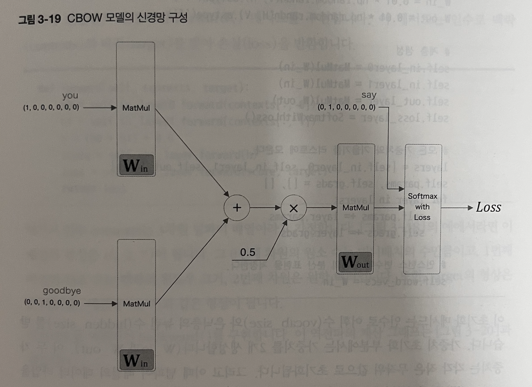
    - 위 그림의 신경망을 SimpleCBOW 라는 이름으로 구현

In [271]:
class MatMul:
    def __init__(self, W):
        self.params = [W]
        self.grads = [np.zeros_like(W)]
        self.x = None

    def forward(self, x):
        W, = self.params
        out = np.dot(x, W)
        self.x = x
        return out

    def backward(self, dout):
        W, = self.params
        dx = np.dot(dout, W.T)
        dW = np.dot(self.x.T, dout)
        self.grads[0][...] = dW
        return dx

In [272]:
def softmax(x):
    if x.ndim == 2:
        x = x - x.max(axis=1, keepdims=True)
        x = np.exp(x)
        x /= x.sum(axis=1, keepdims=True)
    elif x.ndim == 1:
        x = x - np.max(x)
        x = np.exp(x) / np.sum(np.exp(x))

    return x

def cross_entropy_error(y, t):
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)
        
    # 정답 데이터가 원핫 벡터일 경우 정답 레이블 인덱스로 변환
    if t.size == y.size:
        t = t.argmax(axis=1)
             
    batch_size = y.shape[0]

    return -np.sum(np.log(y[np.arange(batch_size), t] + 1e-7))

In [273]:
class SoftmaxWithLoss:
    def __init__(self):
        self.params, self.grads = [], []
        self.y = None  # softmax의 출력
        self.t = None  # 정답 레이블

    def forward(self, x, t):
        self.t = t
        self.y = softmax(x)

        # 정답 레이블이 원핫 벡터일 경우 정답의 인덱스로 변환
        if self.t.size == self.y.size:
            self.t = self.t.argmax(axis=1)

        loss = cross_entropy_error(self.y, self.t)
        return loss

    def backward(self, dout=1):
        batch_size = self.t.shape[0]

        dx = self.y.copy()
        dx[np.arange(batch_size), self.t] -= 1
        dx *= dout
        dx = dx / batch_size

        return dx

In [274]:
class SimpleCBOW:
    def __init__(self, vocab_size, hidden_size):
        V, H = vocab_size, hidden_size

        # 가중치 초기화
        W_in = 0.01 * np.random.randn(V, H).astype('f')
        W_out = 0.01 * np.random.randn(H, V).astype('f')

        # 계층 생성
        self.in_layer0 = MatMul(W_in)
        self.in_layer1 = MatMul(W_in)
        self.out_layer = MatMul(W_out)
        self.loss_layer = SoftmaxWithLoss()

        # 모든 가중치와 기울기를 리스트에 모은다.
        layers = [self.in_layer0, self.in_layer1, self.out_layer]
        self.params, self.grads = [], []
        for layer in layers:
            self.params += layer.params
            self.grads += layer.grads

        # 인스턴스 변수에 단어의 분산 표현을 저장한다.
        self.word_vecs = W_in

    def forward(self, contexts, target):
        h0 = self.in_layer0.forward(contexts[:, 0])
        h1 = self.in_layer1.forward(contexts[:, 1])
        h = (h0 + h1) * 0.5
        score = self.out_layer.forward(h)
        loss = self.loss_layer.forward(score, target)
        return loss

    def backward(self, dout=1):
        ds = self.loss_layer.backward(dout)
        da = self.out_layer.backward(ds)
        da *= 0.5
        self.in_layer1.backward(da)
        self.in_layer0.backward(da)
        return None
    


- __init__() 이 초기화 메서드는 인수로 어휘 수(vocab_size), 은닉층의 뉴런 수(hidden_size)를 받음, 가중치 초기화 부분에서는 가중치를 2개 생성(W_in, W_out), 이 두개의 가중치는 각각 무작위 값으로 초기화, 그리고 그 값은 float32, 32비트 부동소수점 수로 초기화
- 이어서 필요한 계층 생성, 입력 측의 MatMul 계층을 2개, 출력 측의 MatMul 계층을 하나, 그리고 Sofrmax with Loss 계층을 하나 생성, 여기서 입력 측의 맥락을 처리하는 MatMul 계층은 맥락에서 사용하는 단어의 수(윈도우 크기)만큼 만들어야 함(현재 2개), 그리고 입력 측 MatMul 계층들은 모두 같은 가중치를 이용하도록 초기화
- 마지막으로 이 신경망에서 사용되는 매개변수와 기울기를 인스턴스 변수인 params와 grads 리스트에 각각 모음
- 위 코드에서는 여러 계층에서 가중치를 공유, 따라서 params 리스트에는 같은 가중치가 여러 개 존재하게 됨, 이렇게 되면 Adam이나 Momentum 등의 옵티마이저 처리가 본래의 동작고 달라짐, 그래서 Trainer 클래스 내부에서는 매개변수를 갱신 할 때 매개변수의 중복을 없애는 간단한 작업 수행 필요

- forward() 메서드의 매개변수 contexts는 3차원 넘파이 배열이라고 가정, 아래 그림에서라면 이 배열의 형상은 (6, 2, 7)이 됨
- 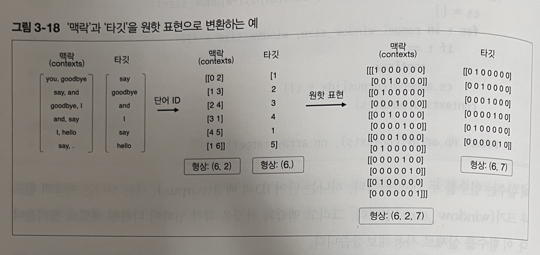
- 0번째 차원의 원소 수는 미니배치의 수, 1번째 차원의 원소 수는 맥락의 윈도우 크기, 2번째 차원은 원핫 벡터, 또한 target의 형상은 2차원으로 (6, 7)과 같은 형상

- backward, 역전파 함수, 역전파의 계산 그래프는 아래 그림과 같음
- 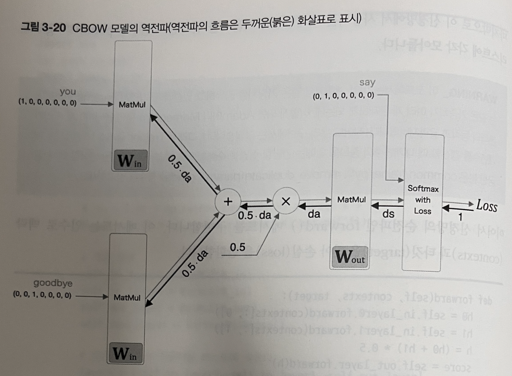
- 신경망의 역전파는 기울기를 순전파 때와는 반대 방향으로 전파, 이 역전파는 1에서 시작하여 곧바로 Softmax with Loss 계층에 입력, 그리고 Softmax with Loss 계층의 역전파 출력이 ds이며, 이 ds를 출력 측 MatMul 계층으로 입력
- 그런 다음 "x"와 "+" 연산으로 역전파, "x"의 연전파는 순전파 시의 입력을 서로 바꿔 기울기를 곱함, "+"의 역전파는 기울기를 그대로 통과 

- 3.4.1 학습 코드 구현
    - CBOW 모델의 학습은 일반적인 신경망의 학습과 완전히 같음, 학습 데이터를 준비해 신경망에 입력한 다음, 기울기를 구하고 가중치 매개변수를 순서대로 갱신

In [275]:
def clip_grads(grads, max_norm):
    total_norm = 0
    for grad in grads:
        total_norm += np.sum(grad ** 2)
    total_norm = np.sqrt(total_norm)

    rate = max_norm / (total_norm + 1e-6)
    if rate < 1:
        for grad in grads:
            grad *= rate

def remove_duplicate(params, grads):
    # 매개변수 배열 중 중복되는 가중치를 하나로 모아 그 가중치에 대응하는 기울기를 더함

    params, grads = params[:], grads[:]     # copy list

    while True:
        find_flg = False
        L = len(params)

        for i in range(0, L - 1):
            for j in range(i + 1, L):
                # 가중치 공유 시
                if params[i] is params[j]:  
                    grads[i] += grads[j]    # 경사를 더함
                    find_flg = True
                    params.pop(j)
                    grads.pop(j)
                # 가중치를 전치행렬로 공유하는 경우 (weight tying)
                elif params[i].ndim == 2 and params[j].ndim == 2 and \
                     params[i].T.shape == params[j].shape and \
                     np.all(params[i].T == params[j]):
                    grads[i] += grads[j].T
                    find_flg = True
                    params.pop(j)
                    grads.pop(j)
                
                if find_flg == True:
                    break
            if find_flg == True:
                break
        
        if not (find_flg == True):
            break
    
    return params, grads

In [281]:
import time
import numpy as np
import matplotlib.pyplot as plt

class Trainer:
    def __init__(self, model, optimizer):
        self.model = model
        self.optimizer = optimizer
        self.loss_list = []
        self.eval_interval = None
        self.current_epoch = 0

    def fit(self, x, t, max_epoch=10, batch_size=32, max_grad=None, eval_interval=20):
        data_size = len(x)
        max_iters = data_size // batch_size
        self.eval_interval = eval_interval
        model, optimizer = self.model, self.optimizer
        total_loss = 0
        loss_count = 0

        start_time = time.time()
        for epoch in range(max_epoch):
            # 뒤섞기
            idx = np.random.permutation(np.arange(data_size))
            x = x[idx]
            t = t[idx]

            for iters in range(max_iters):
                batch_x = x[iters*batch_size:(iters+1)*batch_size]
                batch_t = t[iters*batch_size:(iters+1)*batch_size]

                # 기울기 구해 매개변수 갱신
                loss = model.forward(batch_x, batch_t)
                model.backward()
                params, grads = remove_duplicate(model.params, model.grads)  # 공유된 가중치를 하나로 모음
                if max_grad is not None:
                    clip_grads(grads, max_grad)
                optimizer.update(params, grads)
                total_loss += loss
                loss_count += 1

                # 평가
                if (eval_interval is not None) and (iters % eval_interval) == 0:
                    avg_loss = total_loss / loss_count
                    elapsed_time = time.time() - start_time
                    print('| 에폭 %d |  반복 %d / %d | 시간 %d[s] | 손실 %.2f'
                          % (self.current_epoch + 1, iters + 1, max_iters, elapsed_time, avg_loss))
                    self.loss_list.append(float(avg_loss))
                    total_loss, loss_count = 0, 0

            self.current_epoch += 1

    def plot(self, ylim=None):
        x = np.arange(len(self.loss_list))
        if ylim is not None:
            plt.ylim(*ylim)
        plt.plot(x, self.loss_list, label='train')
        plt.xlabel('repeat (x' + str(self.eval_interval) + ')')
        plt.ylabel('loss')
        plt.show()

In [277]:
class Adam:
    # Adam (http://arxiv.org/abs/1412.6980v8)

    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.iter = 0
        self.m = None
        self.v = None

    def update(self, params, grads):
        if self.m is None:
            self.m, self.v = [], []
            for param in params:
                self.m.append(np.zeros_like(param))
                self.v.append(np.zeros_like(param))
        
        self.iter += 1
        lr_t = self.lr * np.sqrt(1.0 - self.beta2 ** self.iter) / (1.0 - self.beta1 ** self.iter)

        for i in range(len(params)):
            self.m[i] += (1 - self.beta1) * (grads[i] - self.m[i])
            self.v[i] += (1 - self.beta2) * (grads[i] ** 2 - self.v[i])

            params[i] -= lr_t * self.m[i] / (np.sqrt(self.v[i]) + 1e-7)

| 에폭 1 |  반복 1 / 2 | 시간 0[s] | 손실 5.84
| 에폭 2 |  반복 1 / 2 | 시간 0[s] | 손실 5.84
| 에폭 3 |  반복 1 / 2 | 시간 0[s] | 손실 5.84
| 에폭 4 |  반복 1 / 2 | 시간 0[s] | 손실 5.84
| 에폭 5 |  반복 1 / 2 | 시간 0[s] | 손실 5.84
| 에폭 6 |  반복 1 / 2 | 시간 0[s] | 손실 5.84
| 에폭 7 |  반복 1 / 2 | 시간 0[s] | 손실 5.84
| 에폭 8 |  반복 1 / 2 | 시간 0[s] | 손실 5.84
| 에폭 9 |  반복 1 / 2 | 시간 0[s] | 손실 5.83
| 에폭 10 |  반복 1 / 2 | 시간 0[s] | 손실 5.83
| 에폭 11 |  반복 1 / 2 | 시간 0[s] | 손실 5.83
| 에폭 12 |  반복 1 / 2 | 시간 0[s] | 손실 5.83
| 에폭 13 |  반복 1 / 2 | 시간 0[s] | 손실 5.83
| 에폭 14 |  반복 1 / 2 | 시간 0[s] | 손실 5.83
| 에폭 15 |  반복 1 / 2 | 시간 0[s] | 손실 5.83
| 에폭 16 |  반복 1 / 2 | 시간 0[s] | 손실 5.83
| 에폭 17 |  반복 1 / 2 | 시간 0[s] | 손실 5.83
| 에폭 18 |  반복 1 / 2 | 시간 0[s] | 손실 5.83
| 에폭 19 |  반복 1 / 2 | 시간 0[s] | 손실 5.82
| 에폭 20 |  반복 1 / 2 | 시간 0[s] | 손실 5.82
| 에폭 21 |  반복 1 / 2 | 시간 0[s] | 손실 5.82
| 에폭 22 |  반복 1 / 2 | 시간 0[s] | 손실 5.82
| 에폭 23 |  반복 1 / 2 | 시간 0[s] | 손실 5.81
| 에폭 24 |  반복 1 / 2 | 시간 0[s] | 손실 5.81
| 에폭 25 |  반복 1 / 2 | 시간 0[s] | 손실 5.81
| 에폭 26 |

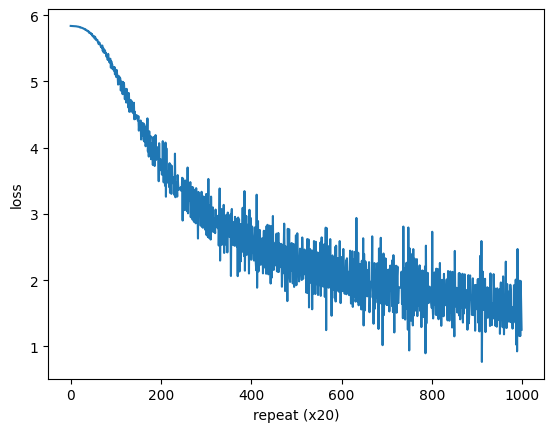

In [282]:
window_size = 1
hidden_size = 5
batch_size = 3
max_epoch = 1000

text = "You say goodbye and I say hello."
corpus, word_to_id, id_to_word = preprocess(text)

vocab_size = len(word_to_id)
contexts, target = create_contexts_target(corpus, window_size)
target = convert_one_hot(target, vocab_size)
contexts = convert_one_hot(contexts, vocab_size)

model = SimpleCBOW(vocab_size, hidden_size)
optimizer = Adam()
trainer = Trainer(model, optimizer)

trainer.fit(contexts, target, max_epoch=max_epoch, batch_size=batch_size)
trainer.plot()

- 매개변수 갱신 방법으로는 Adam 으로 진행
- 그래프와 같이 학습을 진행할수록 손실이 줄어듬

In [283]:
word_vecs = model.word_vecs
for word_id, word in id_to_word.items():
    print(word, word_vecs[word_id])

you [-1.0716058   1.0449578   1.064498   -1.5822427   0.95183605]
say [ 1.2377898 -1.0829582 -1.2358354  0.3930384 -1.2343186]
goodbye [-0.86315435  1.0355422   0.8033329  -0.21080816  0.96569616]
and [ 1.0154026  -0.29703313 -1.0289763   1.8036261  -0.9978715 ]
i [-0.8897639   1.0488284   0.81781584 -0.20299914  1.0041842 ]
hello [-1.0543642  1.0341146  1.0725313 -1.5849333  0.9498999]
. [ 1.080312  -1.2765967 -1.0528728 -1.7374055 -1.1470126]


- 위 코드는 word_vecs라는 이름으로 가중치는 꺼내는데, word_vecs의 각 행에는 대응하는 단어ID의 분산 표현이 저장되어 있음
- 위에서와 같이 단어를 밀집벡터로 나타낼 수 있게 됨, 이 밀집벡터가 바로 단어의 분산 표현, 학습이 잘 이루어졌으니 이 분산 표현은 단어의 의미를 잘 파악한 벡터 표현으로 되어 있을 거라고 생각할 수 있음
- 다만 현재는 아주 작은 말뭉치로 진행했기 때문에 좋은 결과라 하기 어려움

- 3.5 word2vec 보충
    - CBOW 모델을 확률 관점에서 다시 파악

- 3.5.1 CBOW 모델롸 확률
    - 먼저 확률의 표기법을 간단하게 설명, 여기서는 확률을 P(·)으로 작성, 예컨데 A라는 현상이 일어날 확률은 P(A)라고 씀, 또 동시확률은 P(A,B)로 씀, 동시확률이란 A와 B가 동시에 일어날 확률
    - 사후 확률은 P(A|B)로 씀, 이는 말 그래도 사건이 일어난 후의 확률 B(라는 정보)가 주어졌을 때 A가 일어날 확률
    - CBOW 모델을 확률표시법으로 기술, CBOW 모델이 하는 일은 맥락을 주면 타겟 단어가 출현할 확률을 출력하는 것, 여기서는 말뭉치를 w_1, w_2,...w_t 처런 단어 시퀀스로 표기하고 아래 그림 처럼 t번째 단어에 대해 윈도우 크기가 1인 맥락을 고려해 진행
    - 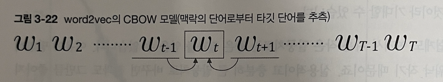
    - 맥락으로 w_t-1과 w_t+1이 주어졌을 때 타겟이 w_t가 될 확률은 수식으로는 아래 이미지처럼 쓸수 있음
    - 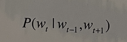
    - 위 식은 w_t-1과 w_t+1이 일어난 후 w_t가 일어날 확률을 뜻함 그리고 w_t-1과 w_t+1이 주어졌을 때 w_t가 일어날 확률로 해석 가능, 즉 CBOW는 위 식을 모델링하고 있는 것
    - 위 식을 이용하면 CBOW 모델의 손실 함수도 간결하게 표현 가능 아래의 교차 엔트로피 오차 식을 보면
    - 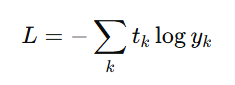
    - 위 식에서 y_k는 k번째에 해당하는 사건이 일어날 확률을 뜻함, 그리고 t_k는 정답 레이블이며 원핫 벡터로 표현, 여기서 문제의 정답은 w_t가 발생이므로 w_t에 해당하는 원소만 1이고 나머지는 0(즉, w_t이외의 일이 일어날 확률에 대해서는 해당 원핫 레이블의 요소는 0), 이점을 감안 하면 아래 식을 유도할 수 있음
    - 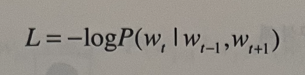
    - 위 식에서 보듯 CBOW 모델의 손실 함수는 단순히 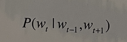 의 확률에 log를 취한 다음 마이너스를 붙이면 됨, 참고로 이를 음의 로그 가능도하 함, 덧붙여 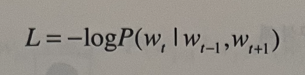 는 샘플데이터 하나에 대한 손실 함수 이며 이를 말뭉치 전체로 확장하면 다음 식이 됨
    - 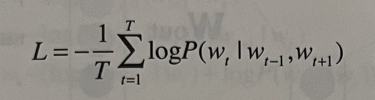
    - CBOW 모델의 학습이 수행하는 일은 위 손실함수의 값을 가능한 작게 만드는 것, 그리고 이때의 가중치 매개변수가 얻고자 하는 단어의 분산 표현, 여기서는 윈도우 크기가 1인 경우만 고려했지만 다른 크기(m 등의 범용적인 크기)라 해도 수식으로 표시 가능

- 3.5.2 skip-gram 모델
    - word3vec은 2개의 모델을 제안하고 있는데 CBOW 모델과 다른 하나는 skip-gram 모델, skip-gram은 CBOW에서 다루는 맥락과 타겟을 역전시킨 모델, 아래 그림 참조
    - 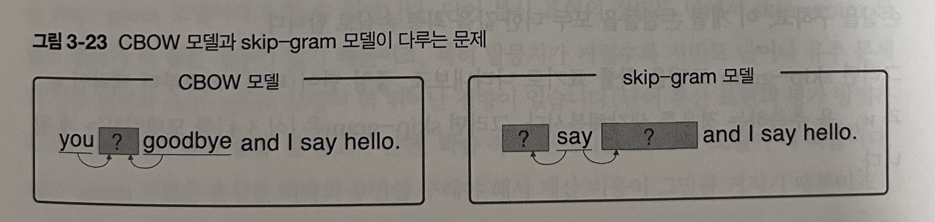
    - 위 그림과 같이 CBOW 모델은 맥락이 여러개 있고, 그 여러 맥락으로부터 중앙의 단어(타겟)를 추측, 한현 skip-gram 모델은 중앙의 단어(타겟)로 부터 주변의 여러 단어(맥락)를 추측
    - skip-gram 모델의 신경망 구성은 아래 그림과 같음
    - 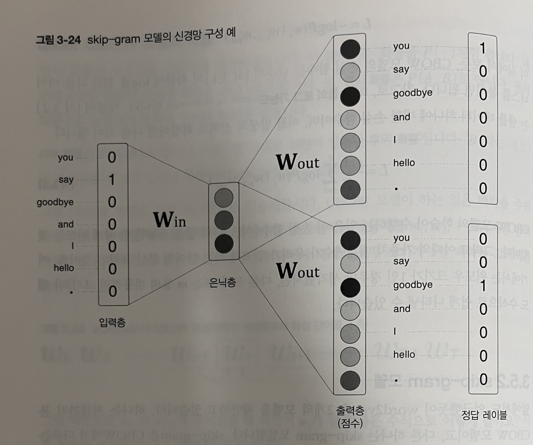
    - 위 그림에서 보듯 skip-gram 모델의 입력층은 하나, 한편 출력층은 맥락의 수만큼 존재, 따라서 각 출력층에서는 (Softmax with Loss 계층 등을 이용해) 개별적으로 손실을 구하고, 이 개별 손실들을 모두 더한 값을 최종 손실로 함
    - 그ㅓ면 skip-gram 모델을 확률 표기로 나타내면, 중앙 단어(타겟), w_t로 부터 맥락인 w_t-1, w_t+1을 추측하는 경우는 skip-gram은 아래 식을 모델링하게 됨
    - 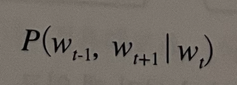
    - 위 식은 w_t가 주어졌을 때 w_t-1, w_t+1 이 동시에 일어날 확률을 뜻함, 여기서 skip-gram 모델에서는 맥락의 단어들 사이에 관계성이 없다고 가정하고(정확하게는 조건부 독립이라고 가정) 아래 그림과 같이 분해
    - 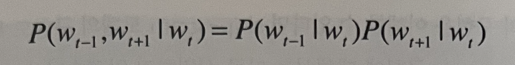
    - 이어서 위 식에 교차 엔트로피 오차를 적용하여 skip-gram 모델의 손실 함수를 유도하면 아래 그림과 같음
    - 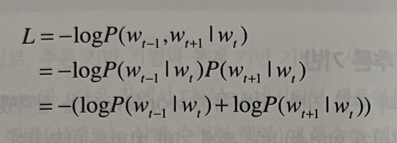
    - 이 유도 과정에서는 logxy = logx + logy 라는 로그의 성질을 이용, 위 식에서 알수 있듯, skip-gram 모델의 손실 함수는 맥락별 손실을 구한 다음 모두 더함, 그리고 위식은 샘플 데이터 하나짜리 skip-gram의 손실 함수 이를 말뭉치 전체로 확장하면 skip-gram 모델의 손실함수는 아래와 같음
    - 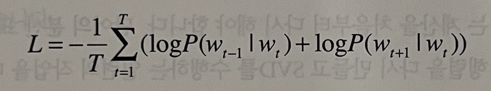
    - 위 식을 아래의 CBOW의 손실 함수 식과 비교
    - 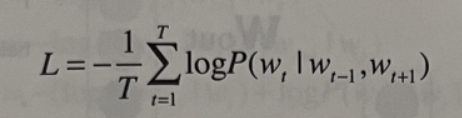
    - skip-gram 모델은 맥락의 수만큼 추측하기 때문에 그 손실 함수는 각 맥략에서 구한 손실으 총합이어야 함, 반면 CBOW 모델은 타겟 하나의 손실을 구함
    - 두 모델 중 단더 분산 표현의 정밀도 면에서 skip-gram 모델의 결과가 더 우수한 편, 특히 말뭉치가 커질수록 저빈도 단어나 유추 문제의 성능이 더 뛰어난 경향, 반면 학습 속도 면에서는 CBOW 모델이 더 빠름, skip-gram 모델은 손실을 맥락의 수만큼 구해야 해서 계산비용이 그만큼 커짐
    - skip-gram 모델은 하나의 단어로부터 그 주변 단어들을 예측, 이는 꽤 어려운 문제인데 아래 그림과 같은 문제
    - 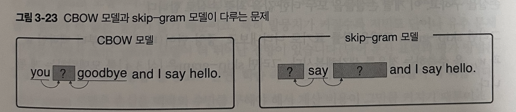
    - 해당 문제를 사람이 직접 푼다고 생각해 본다면 CBOW 모델의 문제는 say 라고 쉽게 답할 수 있지만, skip-gram 모델의 문제라면 어려 가지 후보가 떠오르게 됨, 이런 점에서 skip-gram 모델 쪽이 더 어려운 문제어 도전한다고 할 수 있음, 그리거 더 어려운 상황에서 학습하는 만큼 skip-gram 모델이 내어 주는 단어의 분산 표현이 더 뛰어날 가능성이 커짐.

- 3.5.3 통계 기반 vs. 추론 기반
    - 통계 기반 기법은 말뭉치의 전체 통계로부터 1회 학습하여 단어의 분산 표현을 얻음, 한편 추론 기반 기법에서는 말뭉치를 일부분씩 어러번 보면서 학습(미니배치 학습), 이 학습 방법 외어 두 기법의 차이 확인
    - 아휘에 추가할 새 단어가 생겨 단어의 분산 표현을 갱신해야 하는 경우, 통계 기반 기법에서는 계산을 처음부터 다시해야 함, 단어의 분산 표현을 조금만 수정하고 싶어도 동시발생 행렬을 다시 만들고 SVD를 수해하는 일련의 작업을 다시 해야 함, 그에 반해 추론 기반 기법(word2vec)은 매개변수를 다시 학습 가능, 지금까지 학습한 가중치를 초기값으로 사용해 다시 학습을 진행하면 되는데 이런 특성 덕분에 기존에 학습한 경험을 해치지 않으면서 단어의 분산 표현을 효율적으로 갱신 가능
    - 분산 표햔의 성격이나 정밀도 면에서 본다면 통계 기반 기법에서는 주로 단어의 유사성이 인코딩됨, 한편 word2vec(특히 skip-gram 모델)에서는 단어의 유사성은 물론 한층 복잡한 단어 사이의 패턴까지도 파악되어 인코딩, word2vec은 king-man + woman = queen 과 같은 유추 문제를 풀 수 있는데, 바로 이 특성을 반증
    - 이런 이유로 추론 기반 기법이 통계 기반 기법보다 정확하다고 오해 하지만 정량 테스트 결과 두 기법이 큰 차이는 없었음
    - 추론 기반 기법과 통계 기반 기법은 서로 관련되어 있음, 구체적으로는 skip-gram과 네거티브 샘플링을 이용한 모델은 모두 말뭉치 전체의 동시발생 행렬(실제로는 살짝 수정된 행렬)에 특수한 행렬 분해를 적용한 것과 같은, 두 가법은 특정 조건 하에 연결되어 있는 형태

- 3.6 정리
    - 이번 장에서는 word2vec의 CBOW 모델을 자세히 설명하고 구현, CBOW 모델은 기본적으로 2층 구성의 단순한 신경망, MatMul 계층과 Softmax with Loss 계층을 사용하여 CBOW 모델을 구축한 다음 이 모델이 작은 말뭉치를 학습할 수 있음을 확인, 다음 장에서 효율적인 몇가지 문제 수정 진행

- 이번 장에서 배운 내용
    - 추론 기반 기법은 추측하는 것이 목적이며, 그 부산물로 단어의 분산표현을 얻을수 있음
    - word2vec은 추론 기반 기법이며, 단순한 2층 신경망
    - word2vec은 skip-gram 모델과 CBOW 모델을 제공
    - CBOW 모델은 여러 단어(맥락)로 부터 하나의 단어(타겟)를 추측
    - 반대로 skip-gram 모델은 하나의 단어(타겟)로 부터 다수의 단어(맥락)를 추측
    - word2vec은 가중치를 다시 학습가능하므로 단어의 분산 표현 갱신이나 새로운 단어 추가를 효율적으로 수행 가능